In [1]:
import mysql.connector 
import pandas as pd 

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="**********",
    database ="financial_risk_system"
)

C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
query = "Select * from customer_features"
df = pd.read_sql(query,conn)
df.head()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12124\199205802.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


,Customer_id,Age,Income,Credit_score,transaction_count,total_spending,avg_transaction_value,total_loans,total_defaults,total_loan_amount,default_rate,default_flag
0,1,55,97575.0,512,3,3378.060059,1126.020020,0,0.0,0.0,0.0,0
1,2,45,105335.0,709,2,1896.730049,948.365025,1,0.0,98352.0,0.0,0
2,3,45,79421.0,418,7,8530.969925,1218.709989,0,0.0,0.0,0.0,0
3,4,51,35188.0,790,6,4561.029892,760.171649,1,0.0,200784.0,0.0,0
4,5,47,101101.0,434,6,5428.189896,904.698316,1,0.0,174948.0,0.0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_id            10000 non-null  int64  
 1   Age                    10000 non-null  int64  
 2   Income                 10000 non-null  float64
 3   Credit_score           10000 non-null  int64  
 4   transaction_count      10000 non-null  int64  
 5   total_spending         10000 non-null  float64
 6   avg_transaction_value  10000 non-null  float64
 7   total_loans            10000 non-null  int64  
 8   total_defaults         10000 non-null  float64
 9   total_loan_amount      10000 non-null  float64
 10  default_rate           10000 non-null  float64
 11  default_flag           10000 non-null  int64  
dtypes: float64(6), int64(6)
memory usage: 937.6 KB


In [4]:
df['default_flag'].value_counts()

default_flag
0    9030
1     970
Name: count, dtype: int64

#### Note -> As we see roughly 9.5% of customers fefaulted which alsp make sense as In real credit system , defaults are rare But it also introduce an important ml challenge called class imbalance.

What and Why class imbalance ?                                                                       
If a model simply predicts “no default” for everyone, it would already achieve about 90% accuracy, which is misleading. That is why later we will evaluate using precision, recall, and ROC-AUC, not just accuracy.

In [5]:
df.describe()

,Customer_id,Age,Income,Credit_score,transaction_count,total_spending,avg_transaction_value,total_loans,total_defaults,total_loan_amount,default_rate,default_flag
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000
mean,5000.50000,42.409300,84718.430800,576.881000,5.000000,5523.116011,999.453233,0.500000,0.496700,6.886558e+04,0.397667,0.097000
std,2886.89568,12.637545,37703.064478,158.847075,2.218939,3398.701975,305.388043,0.696885,1.721362,1.189709e+05,1.399683,0.295973
min,1.00000,21.000000,20008.000000,300.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,2500.75000,31.000000,51887.750000,439.000000,3.000000,3283.737480,814.992146,0.000000,0.000000,0.000000e+00,0.000000,0.000000
50%,5000.50000,42.000000,84741.000000,578.000000,5.000000,5004.155041,999.522069,0.000000,0.000000,0.000000e+00,0.000000,0.000000
75%,7500.25000,53.000000,117246.750000,716.000000,6.000000,7069.242477,1188.368859,1.000000,0.000000,1.050458e+05,0.000000,0.000000
max,10000.00000,64.000000,149997.000000,849.000000,15.000000,39709.920288,1997.810059,5.000000,24.000000,1.150497e+06,14.000000,1.000000


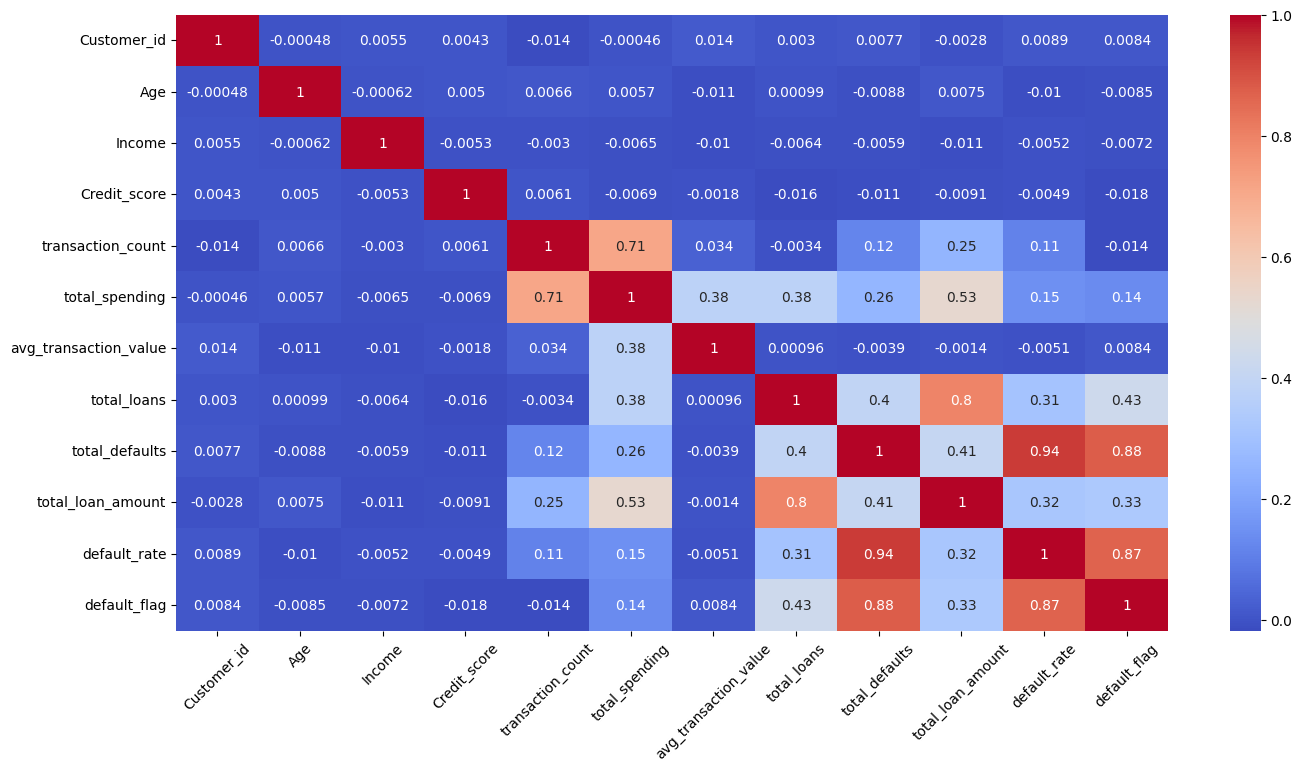

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt 
plt.figure(figsize=(16,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.xticks(rotation=45)
plt.show()